In [4]:
!pip install gradio

/tmp/ipykernel_3338/134645392.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_3338/134645392.py:138: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f91d4b2e6768bd383.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


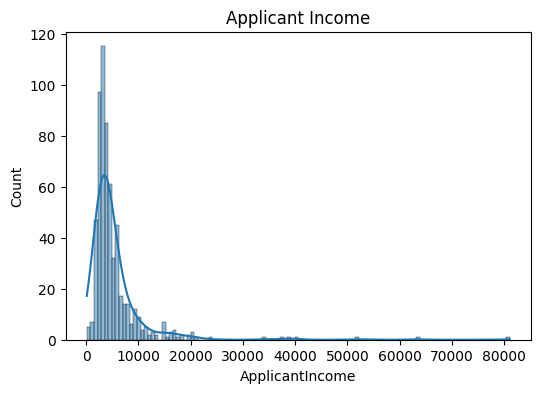

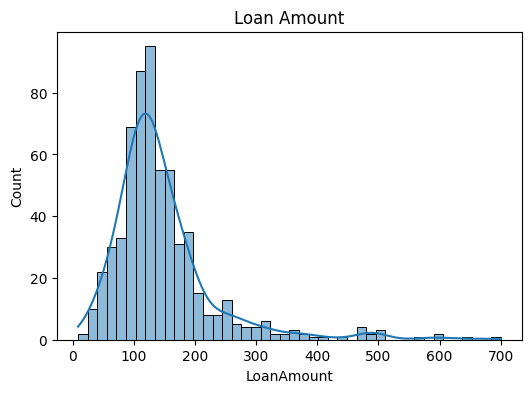

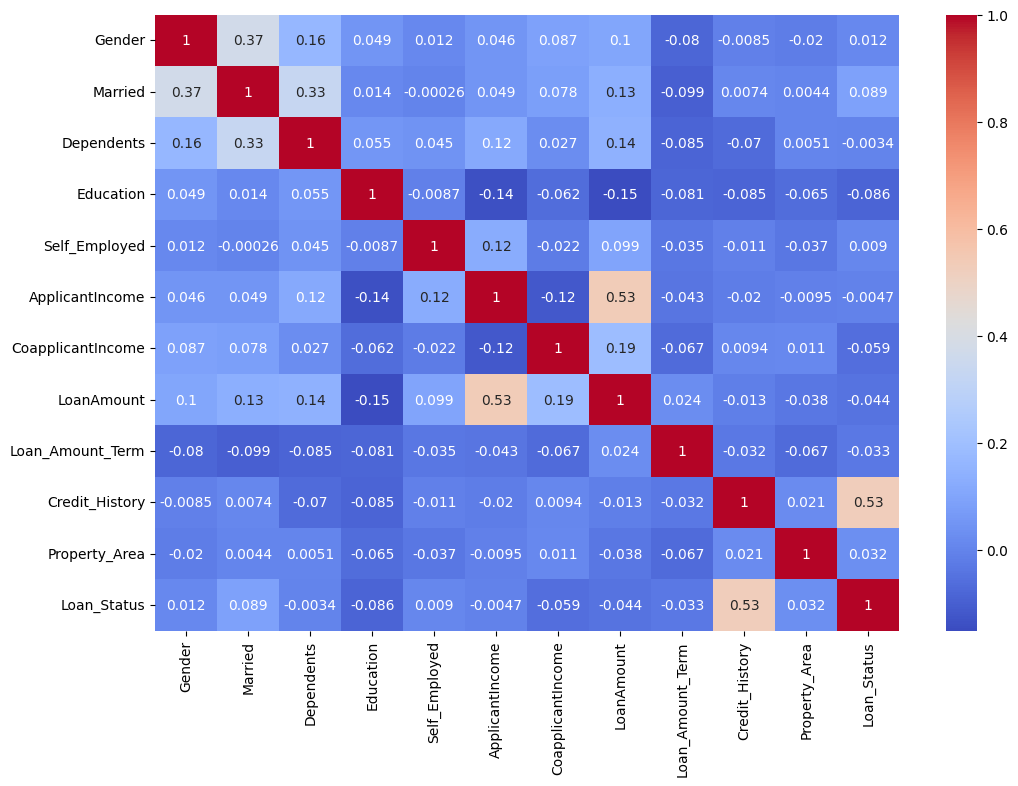

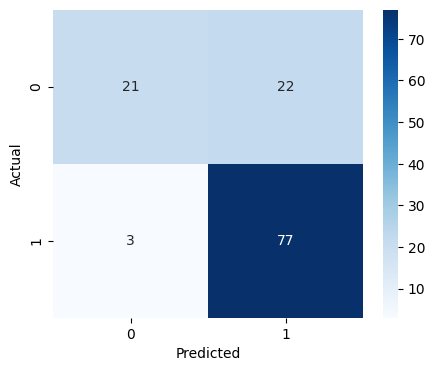

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv("train.csv")

# =========================================
# PREPROCESSING
# =========================================

df.fillna(method='ffill', inplace=True)

encoder = LabelEncoder()

columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in columns:
    df[col] = encoder.fit_transform(df[col])

df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(float)

X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

X = pd.get_dummies(X)

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================
# MODEL TRAINING
# =========================================

model = RandomForestClassifier()

model.fit(X_train, y_train)

# =========================================
# ACCURACY
# =========================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_test, y_pred)

# =========================================
# PREDICTION FUNCTION
# =========================================

def predict_loan(
    Gender,
    Married,
    Dependents,
    Education,
    Self_Employed,
    ApplicantIncome,
    CoapplicantIncome,
    LoanAmount,
    Loan_Amount_Term,
    Credit_History,
    Property_Area
):

    input_data = pd.DataFrame([[
        Gender,
        Married,
        Dependents,
        Education,
        Self_Employed,
        ApplicantIncome,
        CoapplicantIncome,
        LoanAmount,
        Loan_Amount_Term,
        Credit_History,
        Property_Area
    ]], columns=[
        'Gender',
        'Married',
        'Dependents',
        'Education',
        'Self_Employed',
        'ApplicantIncome',
        'CoapplicantIncome',
        'LoanAmount',
        'Loan_Amount_Term',
        'Credit_History',
        'Property_Area'
    ])

    input_data = pd.get_dummies(input_data)

    input_data = input_data.reindex(columns=X.columns, fill_value=0)

    prediction = model.predict(input_data)[0]

    if prediction == 1:
        return "✅ LOAN APPROVED"
    else:
        return "❌ LOAN REJECTED"

# =========================================
# GRADIO UI
# =========================================

with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🏦 Loan Approval Prediction System

    ### Major Project using Machine Learning
    """)

    # =====================================
    # HOME
    # =====================================

    with gr.Tab("🏠 Home"):

        gr.Markdown("""
        ## Welcome

        This project predicts whether a loan application
        will be approved or rejected using Machine Learning.

        ### Navigation

        - Dataset
        - Preprocessing
        - Graphs
        - Heatmap
        - Model Training
        - Accuracy
        - Confusion Matrix
        - Prediction
        - About
        """)

    # =====================================
    # DATASET
    # =====================================

    with gr.Tab("📂 Dataset"):

        gr.Markdown("## Dataset Preview")

        gr.Dataframe(df.head(10))

    # =====================================
    # PREPROCESSING
    # =====================================

    with gr.Tab("⚙️ Preprocessing"):

        gr.Markdown("## Preprocessed Dataset")

        gr.Dataframe(df.head(10))

    # =====================================
    # GRAPHS
    # =====================================

    with gr.Tab("📊 Graphs"):

        gr.Markdown("## Applicant Income Distribution")

        fig1, ax1 = plt.subplots(figsize=(6,4))

        sns.histplot(
            df['ApplicantIncome'],
            kde=True,
            ax=ax1
        )

        ax1.set_title("Applicant Income")

        gr.Plot(fig1)

        gr.Markdown("## Loan Amount Distribution")

        fig2, ax2 = plt.subplots(figsize=(6,4))

        sns.histplot(
            df['LoanAmount'],
            kde=True,
            ax=ax2
        )

        ax2.set_title("Loan Amount")

        gr.Plot(fig2)

    # =====================================
    # HEATMAP
    # =====================================

    with gr.Tab("🔥 Heatmap"):

        gr.Markdown("## Correlation Heatmap")

        fig3, ax3 = plt.subplots(figsize=(12,8))

        sns.heatmap(
            df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            ax=ax3
        )

        gr.Plot(fig3)

    # =====================================
    # MODEL TRAINING
    # =====================================

    with gr.Tab("🤖 Model Training"):

        gr.Textbox(
            value="MODEL TRAINED SUCCESSFULLY",
            label="Training Status"
        )

    # =====================================
    # ACCURACY
    # =====================================

    with gr.Tab("📈 Accuracy"):

        gr.Textbox(
            value=f"Accuracy Score: {accuracy:.2f}",
            label="Accuracy"
        )

    # =====================================
    # CONFUSION MATRIX
    # =====================================

    with gr.Tab("📉 Confusion Matrix"):

        fig4, ax4 = plt.subplots(figsize=(5,4))

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax4
        )

        ax4.set_xlabel("Predicted")
        ax4.set_ylabel("Actual")

        gr.Plot(fig4)

    # =====================================
    # PREDICTION
    # =====================================

    with gr.Tab("🎯 Prediction"):

        gr.Markdown("## Loan Prediction")

        Gender = gr.Number(label="Gender (0=Female, 1=Male)")
        Married = gr.Number(label="Married (0=No, 1=Yes)")
        Dependents = gr.Number(label="Dependents")
        Education = gr.Number(label="Education (0=Graduate,1=Not Graduate)")
        Self_Employed = gr.Number(label="Self Employed (0=No,1=Yes)")
        ApplicantIncome = gr.Number(label="Applicant Income")
        CoapplicantIncome = gr.Number(label="Coapplicant Income")
        LoanAmount = gr.Number(label="Loan Amount")
        Loan_Amount_Term = gr.Number(label="Loan Amount Term")
        Credit_History = gr.Number(label="Credit History (0/1)")
        Property_Area = gr.Number(label="Property Area (0/1/2)")

        output = gr.Textbox(label="Prediction Result")

        btn = gr.Button("Predict")

        btn.click(
            predict_loan,
            inputs=[
                Gender,
                Married,
                Dependents,
                Education,
                Self_Employed,
                ApplicantIncome,
                CoapplicantIncome,
                LoanAmount,
                Loan_Amount_Term,
                Credit_History,
                Property_Area
            ],
            outputs=output
        )

    # =====================================
    # ABOUT
    # =====================================

    with gr.Tab("ℹ️ About"):

        gr.Markdown("""
        ## About Project

        ### Technologies Used
        - Python
        - Pandas
        - NumPy
        - Scikit-learn
        - Matplotlib
        - Seaborn
        - Gradio

        ### Algorithms Used
        - Random Forest Classifier

        ### Output
        - Loan Approved
        - Loan Rejected
        """)

# =========================================
# LAUNCH
# =========================================

demo.launch(share=True)